In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from fpppy.utils import plot_series
from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL

d:\UPE\Redes Neurais\Pesquisa\Projeto_Forecasting\.venv\Lib\site-packages\fpppy\utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


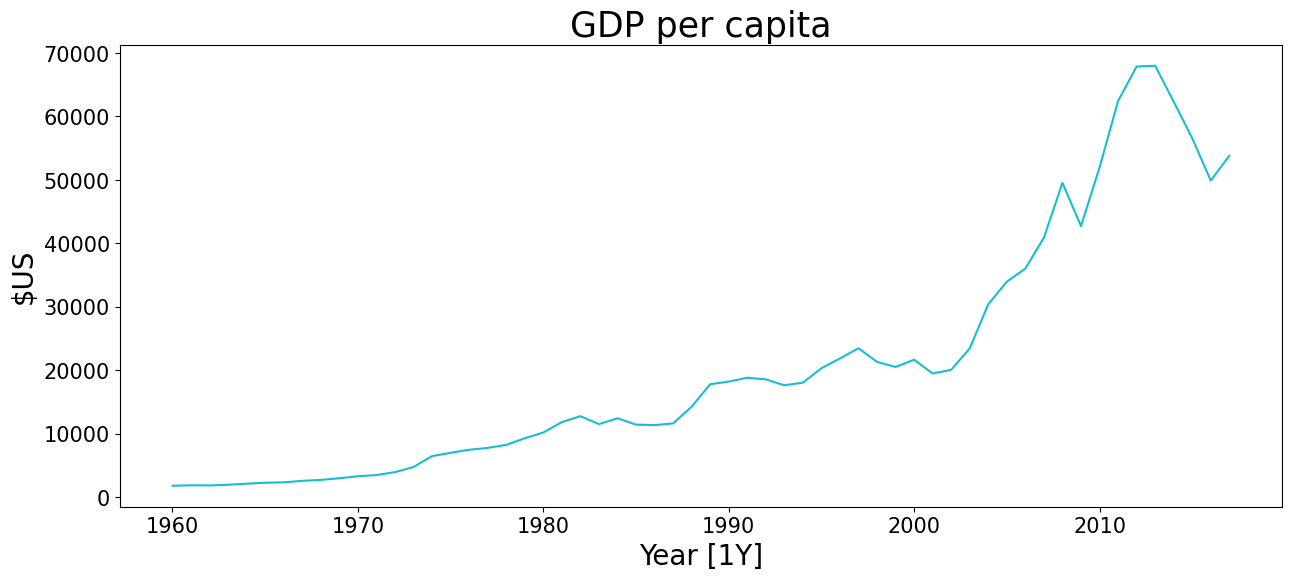

In [2]:
global_economy = pd.read_csv("../data/global_economy.csv")

df = (
    global_economy
    .loc[lambda x: x["unique_id"] == "Australia"]
    .assign(y=lambda x: x["GDP"] / x["Population"])
)
plot_series(df, xlabel="Year [1Y]", ylabel="$US", title="GDP per capita")

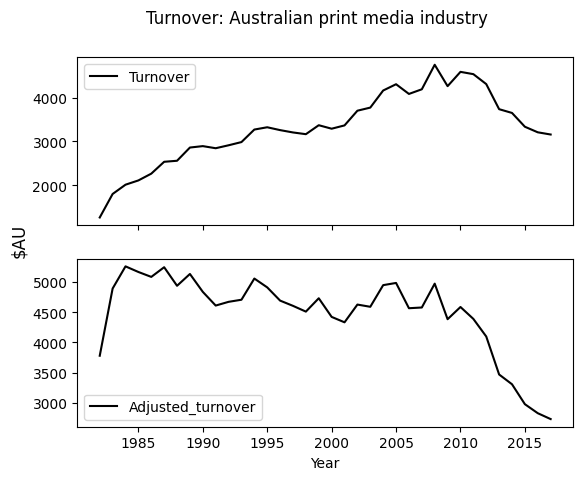

In [3]:
aus_retail = pd.read_csv("../data/aus_retail.csv", parse_dates=["Month"])
print_retail = (
    aus_retail
    .loc[lambda x: x["Industry"] == "Newspaper and book retailing"]
    .assign(ds=lambda x: x["Month"].dt.year)
    .groupby("ds", as_index=False)
    ["Turnover"].sum()
)

aus_economy = global_economy.loc[lambda x: x["unique_id"] == "Australia"]
df = (
    aus_economy
    .merge(print_retail, on="ds", how="left")
    .assign(adjusted_turnover=lambda x: x["Turnover"] / x["CPI"] * 100)
    .dropna()
)

fig, axes = plt.subplots(2, 1, sharex=True)
sns.lineplot(data=df, x='ds', y='Turnover', ax=axes[0],
    color='black', label="Turnover")
sns.lineplot(data=df, x='ds', y='adjusted_turnover', ax=axes[1],
    color='black', label="Adjusted_turnover")
axes[0].set(ylabel="")
axes[1].set(ylabel="", xlabel='Year')
fig.suptitle("Turnover: Australian print media industry")
fig.supylabel("$AU")
plt.show()

d:\UPE\Redes Neurais\Pesquisa\Projeto_Forecasting\.venv\Lib\site-packages\fpppy\utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


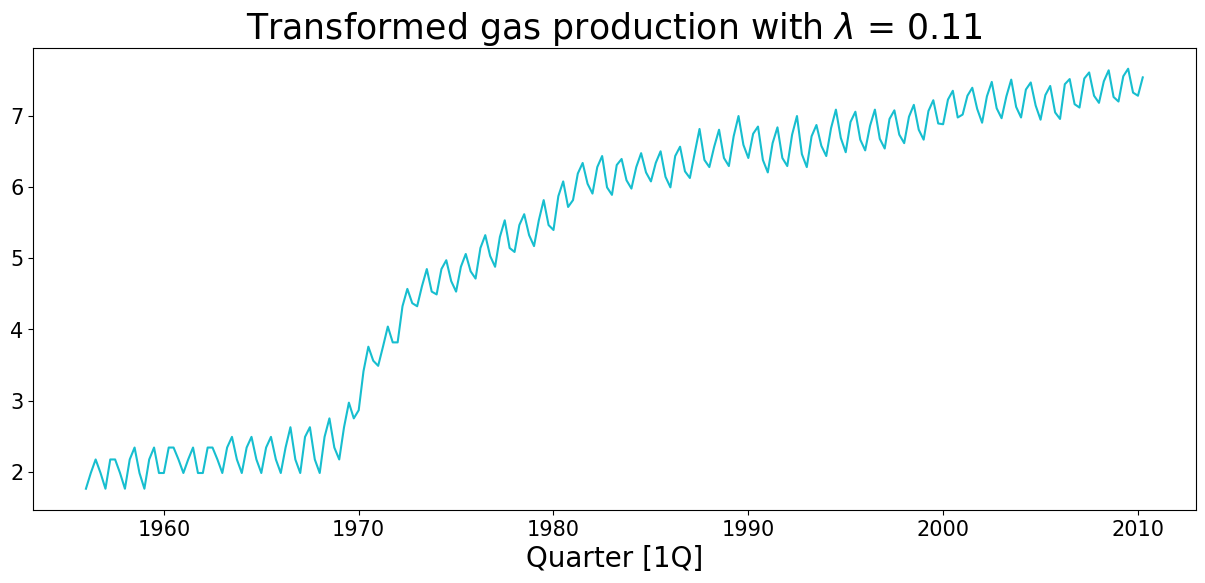

In [6]:
aus_production = pd.read_csv("../data/aus_production.csv",
    parse_dates=["ds"])
aus_gas = (
    aus_production[["ds", "Gas"]]
    .rename(columns={"Gas": "y"})
    .assign(unique_id="Gas")
)

y = aus_gas["y"].to_numpy()
optim_lambda = boxcox_lambda(y, method="guerrero", season_length=4)
df = aus_gas.assign(y_transformed=boxcox(y, optim_lambda))

title = rf"Transformed gas production with $\lambda$ = {optim_lambda:.2f}"
plot_series(df, target_col="y_transformed",
    xlabel="Quarter [1Q]", ylabel="", title=title)

d:\UPE\Redes Neurais\Pesquisa\Projeto_Forecasting\.venv\Lib\site-packages\fpppy\utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


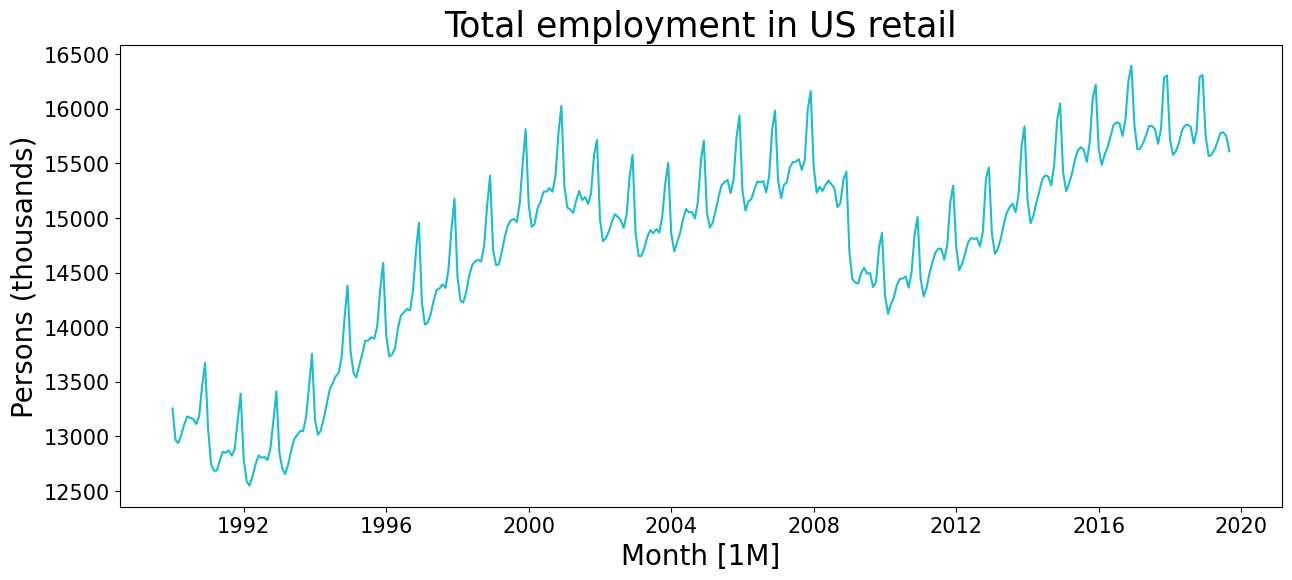

In [7]:
us_employment = pd.read_csv("../data/us_employment.csv", parse_dates=["ds"])
us_retail_employment = us_employment.loc[lambda x:
    (x["unique_id"] == "Retail Trade") & (x["ds"] >= "1990")
]

plot_series(us_retail_employment,
    xlabel="Month [1M]", ylabel="Persons (thousands)",
    title="Total employment in US retail")

In [10]:
stl = STL(us_retail_employment["y"], period=12)
res = stl.fit()

dcmp = pd.DataFrame({
    "ds": us_retail_employment["ds"],
    "data": us_retail_employment["y"],
    "trend": res.trend,
    "seasonal": res.seasonal,
    "remainder": res.resid,
}).reset_index(drop=True)

dcmp.head()

,ds,data,trend,seasonal,remainder
0,1990-01-01,13255.8,13296.248875,-3.699986,-36.748889
1,1990-02-01,12966.3,13276.085176,-288.398325,-21.386851
2,1990-03-01,12938.2,13255.662673,-306.657625,-10.805048
3,1990-04-01,13012.3,13234.986479,-235.775229,13.088750
4,1990-05-01,13108.3,13214.070964,-115.398800,9.627836


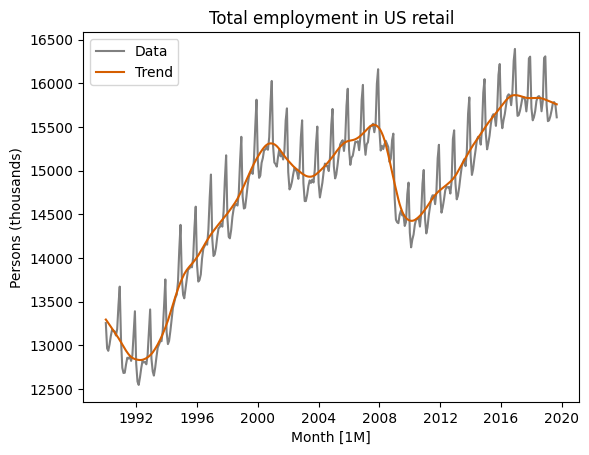

In [11]:
fig, ax = plt.subplots()
sns.lineplot(data=dcmp, x="ds", y="data", color="gray", label="Data")
sns.lineplot(data=dcmp, x="ds", y="trend", color="#D55E00", label="Trend")
ax.set(
    title="Total employment in US retail",
    xlabel="Month [1M]",
    ylabel="Persons (thousands)",
)
plt.show()

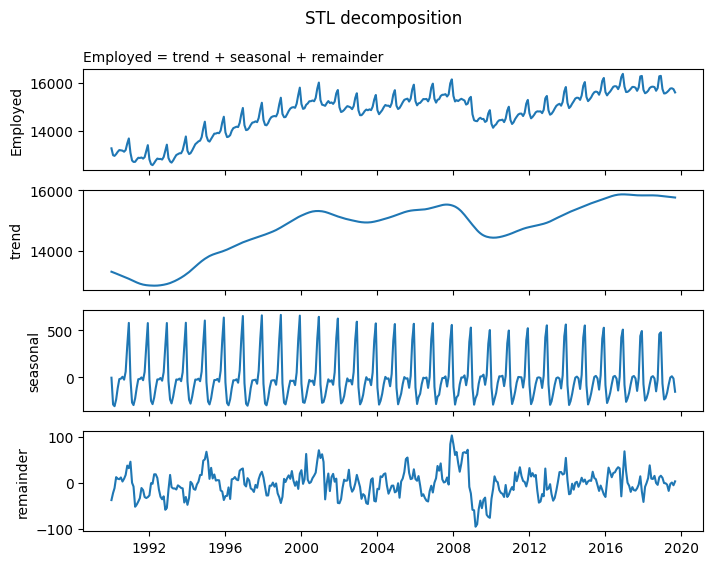

In [12]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 6))
sns.lineplot(data=dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=dcmp, x="ds", y="remainder", ax=axes[3])
axes[0].set_title("Employed = trend + seasonal + remainder",
    size="medium", loc="left")
axes[0].set(ylabel="Employed")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

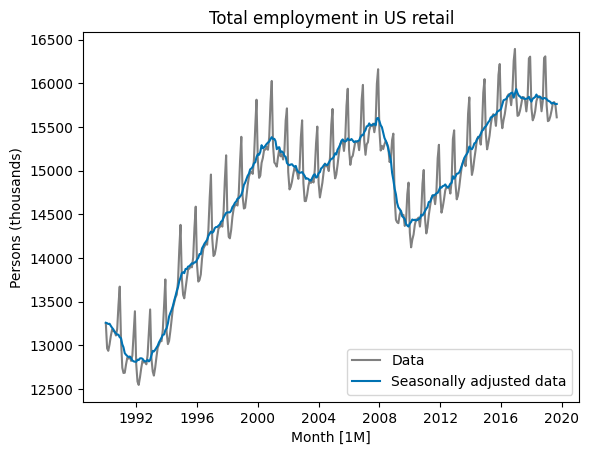

In [13]:
df = dcmp.assign(adj=lambda x: x["data"] - x["seasonal"])

fig, ax = plt.subplots()
sns.lineplot(data=df, x="ds", y="data",
    color="gray", label="Data")
sns.lineplot(data=df, x="ds", y="adj",
    color="#0072B2", label="Seasonally adjusted data")
ax.set(
    title="Total employment in US retail",
    xlabel="Month [1M]",
    ylabel="Persons (thousands)",
)
plt.show()

d:\UPE\Redes Neurais\Pesquisa\Projeto_Forecasting\.venv\Lib\site-packages\fpppy\utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


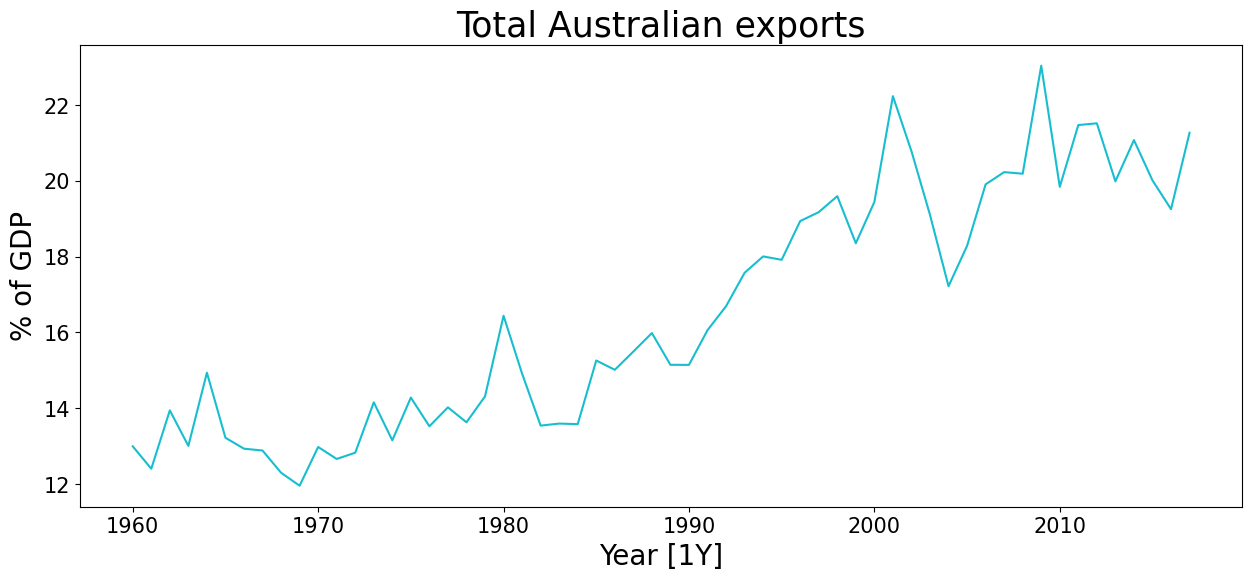

In [14]:
global_economy = pd.read_csv("../data/global_economy.csv")
df = global_economy.loc[lambda x: x["unique_id"] == "Australia"]

plot_series(df, target_col="Exports",
    xlabel="Year [1Y]", ylabel="% of GDP",
    title="Total Australian exports")

In [15]:
aus_exports = (
    global_economy
    .loc[lambda x: x["unique_id"] == "Australia"]
    .assign(MA_5=lambda x: x["Exports"].rolling(5, center=True).mean())
)

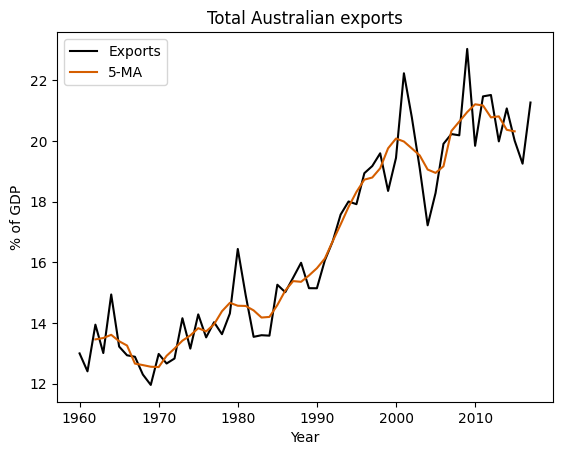

In [16]:
fig, ax = plt.subplots()
sns.lineplot(data=aus_exports, x="ds", y="Exports",
    color="black", label="Exports")
sns.lineplot(data=aus_exports, x="ds", y="MA_5",
    color="#D55E00", label="5-MA")
ax.set(
    title="Total Australian exports",
    xlabel="Year",
    ylabel="% of GDP",
)
plt.show()

In [18]:
aus_production = pd.read_csv("../data/aus_production.csv",
    parse_dates=["ds"])
beer = (
    aus_production[["ds", "Beer"]]
    .loc[lambda x: x["ds"] >= "1992"]
    .reset_index(drop=True)
)
beer["4-MA"] = beer["Beer"].rolling(4, center=True).mean().shift(-1)
beer["2x4-MA"] = beer["4-MA"].rolling(2, center=True).mean()

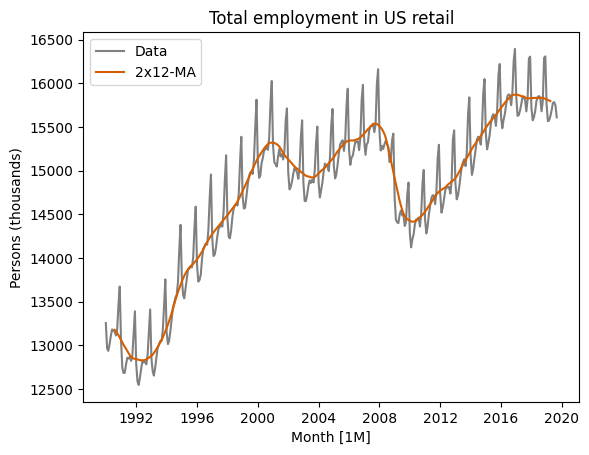

In [19]:
df = us_retail_employment.copy()
df["12-MA"] = df["y"].rolling(window=12, center=True).mean()
df["2x12-MA"] = df["12-MA"].rolling(window=2, center=True).mean()

fig, ax = plt.subplots()
sns.lineplot(data=df, x="ds", y="y",
    color="grey", label="Data")
sns.lineplot(data=df, x="ds", y="2x12-MA",
    color="#D55E00", label="2x12-MA")
ax.set(
    title="Total employment in US retail",
    xlabel="Month [1M]",
    ylabel="Persons (thousands)",
)
plt.show()

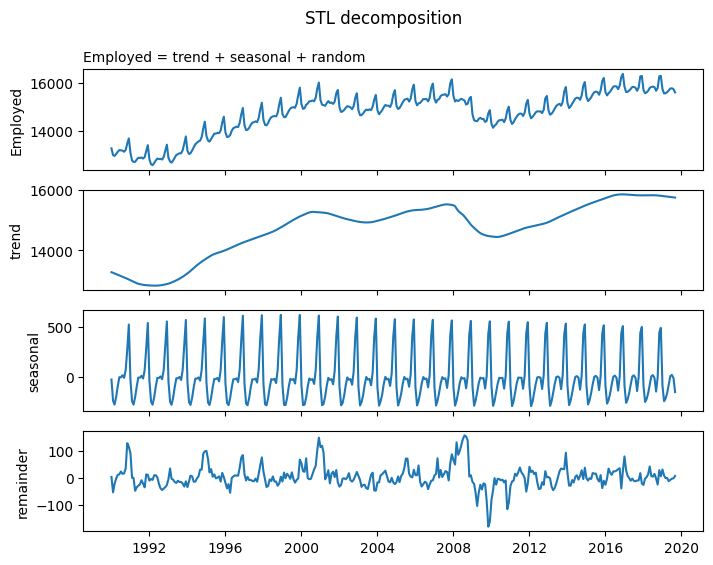

In [20]:
stl = STL(us_retail_employment["y"], period=12,
    seasonal=13, trend=21, robust=True)
res_stl = stl.fit()
dcmp = pd.DataFrame({
    "ds": us_retail_employment["ds"],
    "data": us_retail_employment["y"],
    "trend": res_stl.trend,
    "seasonal": res_stl.seasonal,
    "remainder": res_stl.resid,
}).reset_index(drop=True)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 6))
sns.lineplot(data=dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=dcmp, x="ds", y="remainder", ax=axes[3])
axes[0].set_title("Employed = trend + seasonal + random",
    size="medium", loc="left")
axes[0].set(ylabel="Employed")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()